# Run Ray on a (simulated) cluster

In this notebook, we will experiment with running Ray on a cluster of 5 machines. However, this 5 machine cluster will be simulated via Docker. See Docker lectures for context.

The `docker compose` file and the associated `docker-compose.yaml` file in the folder `ray_cluster` describes the cluster. The yaml file describes the configuration of the machines which make up the cluster and the `compose` sub-command controls the status of the cluster. Additionally, the `Dockerfile` describes the configuration of the individual nodes.

### Matching Python versions
Since we will execute code on our laptop and get it to execute on the remote (simulated) server, we will need to ensure that there is no version mismatch. For this, the following code will tell us the required versions:

In [ ]:
import ray
import sys
import sklearn

print(f"💻 Local Python: {sys.version.split()[0]}")
print(f"📦 Local Sklearn: {sklearn.__version__}")

With this information, we will need to edit `ray_cluster/Dockerfile`

### Once the Dockerfile is updated, use the terminal to navigate to `ray_cluster` and issue the following command:
```bash
docker compose up
```

Once done with this class session, you should end the session via `docker compose down`

Note that you can also control the cluster via Docker Desktop:
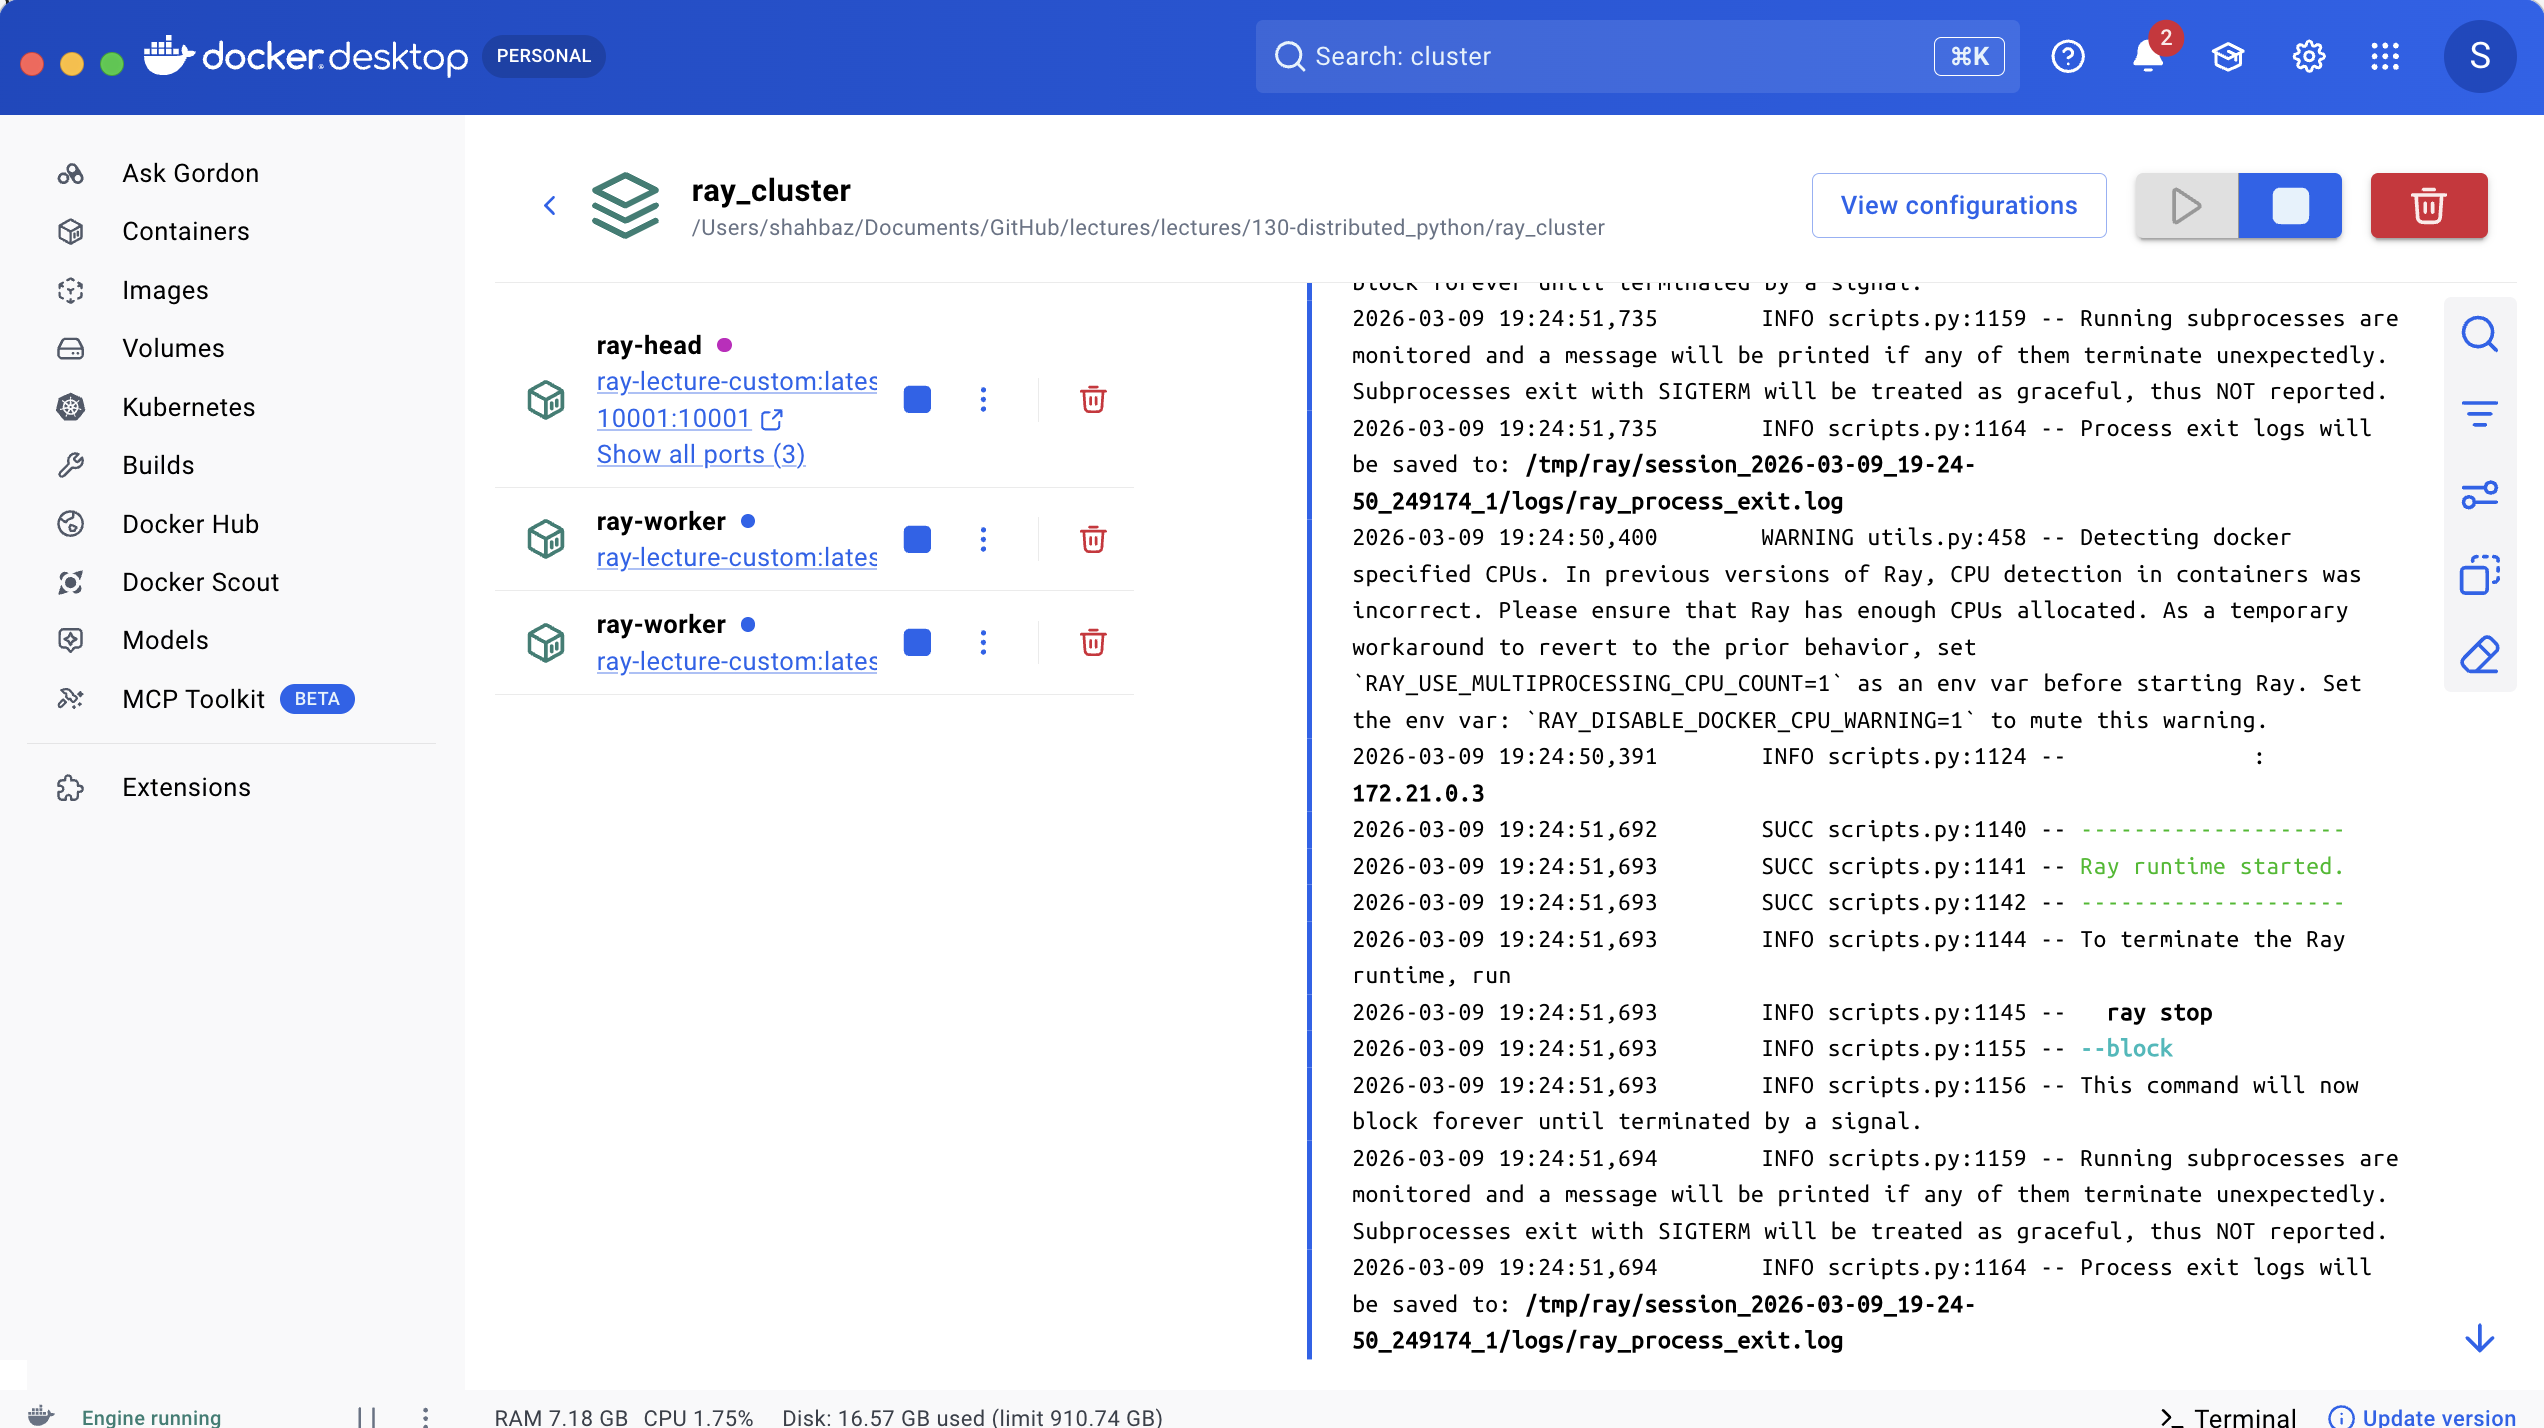

### Now connect to the remote server

In [ ]:
import ray

# Disconnect from any existing local or client cluster before connecting to the Docker cluster
if ray.is_initialized():
    ray.shutdown()

try:
    ray.init("ray://localhost:10001")
    
    # Verification printouts
    print(f"✅ Connected to Ray Cluster!")
    
    # Check what the cluster sees
    print(f"🏗️ Cluster Resources: {ray.cluster_resources()}")
    
except Exception as e:
    print(f"❌ Connection Failed: {e}")
    print("TIP: Ensure your local Python version matches the Dockerfile (py310).")